In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from astropy import units as u
from astropy import constants as const
from astropy.cosmology import Planck18, z_at_value

from scipy.integrate import quad
from scipy.optimize import curve_fit
#from ipynb.fs.full.Generator_trapz import *
#from ipynb.fs.full.Analytic_neutrino_flux import *
from GOALS_dataframe.analytic_neutrino_flux import *


import matplotlib.patches as patches


from gammapy.modeling.models import (
    EBL_DATA_BUILTIN,
    EBLAbsorptionNormSpectralModel,
    Models,
    PowerLawSpectralModel,
    SkyModel,
)




In [3]:
DL = 50.7 * u.Mpc
gammasn=4.11
RSN=0.28
alphaAGN=0.04
z = z_at_value(Planck18.luminosity_distance, DL)
redshift = z.value

franceschini17 = EBLAbsorptionNormSpectralModel.read_builtin(
    "franceschini17", redshift=redshift
)

energyrange=franceschini17.energy.value*1e-6
AbsCoeff=franceschini17.data.value[int(round(redshift,3)*1000)-1]
print(AbsCoeff)
AbsCoeff=AbsCoeff[energyrange>0.1]

energyrange=energyrange[energyrange>0.1]


#Arp299_1= [bulk_flux(i, 2500,250,150,500,0.1,1e10,4.00,1e8,1.86,50.7) for i in energy]
Arp299_a= Flux_gamma(energyrange, R=250,v=500,nism=2500,H=150,gammasn=4.00,pmax=1e8,RSN=1.86,D_L=DL.value)*AbsCoeff*0.00160218

## Flux à n=2500

[1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.000000

In [4]:
#Arp299_2= [bulk_flux(i, 2500,250,150,500,0.1,1e10,4.11,1e8,1.86,50.7) for i in energy]
Arp299_2a= Flux_gamma(energyrange, R=250,v=500,nism=2500,H=150,gammasn=gammasn,pmax=1e8,RSN=1.86,D_L=DL.value)*AbsCoeff*0.00160218



In [5]:
#Arp299_3 = [bulk_flux(i, 2500,250,150,500,0.1,1e10,4.11,1e8,0.28,50.7) for i in energy]
Arp299_3a= Flux_gamma(energyrange, R=250,v=500,nism=2500,H=150,gammasn=gammasn,pmax=1e8,RSN=RSN,D_L=DL.value)*AbsCoeff*0.00160218 #to erg



In [6]:
dataNorth = pd.read_csv('CTAO_data/CTAOdata_North_50h.csv',sep=';', header=None, names=['X','Y'])
dataSouth = pd.read_csv('CTAO_data/CTAOdata_South_50h.csv',sep=';', header=None, names=['X','Y'])
dataARP299 = pd.read_csv('96/ARP299_data.csv',sep=';', header=None, names=['X','Y'])
upperARP299 = pd.read_csv('96/ARP299_upper.csv',sep=';', header=None, names=['X','Y'])
xyminARP299 = pd.read_csv('96/ARP299_xymin.csv',sep=';', header=None, names=['X','Y']) #Uncertainty
xymaxARP299 = pd.read_csv('96/ARP299_xymax.csv',sep=';', header=None, names=['X','Y'])
lowerleftARP299=pd.read_csv('96/ARP299_lowerleft.csv',sep=';', header=None, names=['X','Y']) #Upper Uncertainty
rightARP299=pd.read_csv('96/ARP299_right.csv',sep=';', header=None, names=['X','Y'])

tabdata=[dataNorth,dataSouth,dataARP299,upperARP299,xyminARP299,xymaxARP299,lowerleftARP299,rightARP299]

for i in range(len(tabdata)):
    
    tabdata[i].X=tabdata[i].X.replace(',','.',regex=True)
    tabdata[i].Y=tabdata[i].Y.replace(',','.',regex=True)

XNorth=dataNorth.X.astype('float64')*1e3 # to GeV
YNorth=dataNorth.Y.astype('float64')
XSouth=dataSouth.X.astype('float64')*1e3 # to GeV
YSouth=dataSouth.Y.astype('float64')

XARP299data=dataARP299.X.astype('float64')
YARP299data=dataARP299.Y.astype('float64')*0.00160218 #to erg
XminARP299data=xyminARP299.X.astype('float64')
YminARP299data=xyminARP299.Y.astype('float64')*0.00160218 #to erg
XmaxARP299data=xymaxARP299.X.astype('float64')
YmaxARP299data=xymaxARP299.Y.astype('float64')*0.00160218 #to erg

XARP299upper=upperARP299.X.astype('float64')
YARP299upper=upperARP299.Y.astype('float64')*0.00160218 #to erg
XminARP299upper=lowerleftARP299.X.astype('float64')
YminARP299upper=lowerleftARP299.Y.astype('float64')*0.00160218 #to erg
XmaxARP299upper=rightARP299.X.astype('float64')


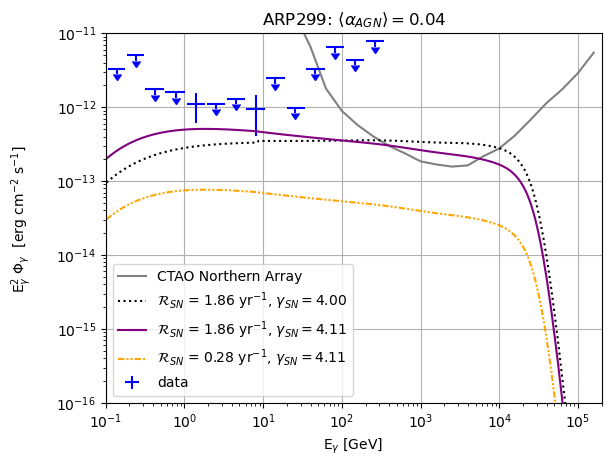

In [7]:
plt.plot(XNorth,YNorth,color="gray",label ="CTAO Northern Array")
#plt.plot(XSouth,YSouth,color="red",label ="CTAO Southern Array")
plt.errorbar(XARP299data,YARP299data,xerr=[XARP299data-XminARP299data,XmaxARP299data-XARP299data], yerr=[YARP299data-YminARP299data,YmaxARP299data-YARP299data], color="blue",fmt=',',label='data')
plt.errorbar(XARP299upper,YARP299upper,xerr=[XARP299upper-XminARP299upper,XmaxARP299upper-XARP299upper], yerr=YARP299upper-YminARP299upper,color="blue",uplims=True,fmt=',')

plt.plot(energyrange, Arp299_a, color = 'black', linestyle = 'dotted', label='$\mathcal{R}_{SN}$ = 1.86 yr$^{-1}$, $\\gamma_{SN} = 4.00$')
plt.plot(energyrange,Arp299_2a, color = 'purple',label= '$\mathcal{R}_{SN}$ = 1.86 yr$^{-1}$, $\\gamma_{SN} = $'+ str(gammasn))
plt.plot(energyrange,Arp299_3a, color = 'orange',linestyle = (0,(3,1,1,1,1,1)),label='$\mathcal{R}_{SN}$ = '+str(RSN)+' yr$^{-1}$, $\\gamma_{SN} = $'+ str(gammasn) )






plt.xscale('log') ; plt.yscale('log')
plt.xlim(1e-1,2e5) ; plt.ylim(1e-16,1e-11)
#plt.xlim(2e2,2e8) ; plt.ylim(9e-16,5e-9) #nu
plt.title(r"ARP299: $ \langle \alpha_{AGN}\rangle=$"+ str(alphaAGN))
plt.xlabel('E$_{\\gamma}$ [GeV] ')
plt.ylabel('E$_{\\gamma}^2$ $\\Phi_{\\gamma}$  [erg cm$^{-2}$ s$^{-1}$] \n')
plt.legend(loc = 'lower left')
plt.grid()

#plt.savefig("./Figures/FluxplotArp299.pdf",bbox_inches="tight",dpi = 200)
